# Visualizing statistical relationships

Statistical analysis is a process of understanding how variables in a dataset relate to each other and how those relationships depend on other variables. Visualization can be a core component of this process because, when data are visualized properly, the human visual system can see trends and patterns that indicate a relationship.



We will discuss three seaborn functions in this tutorial. The one we will use most is [`relplot()`](https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot). This is a [figure-level function](https://seaborn.pydata.org/tutorial/function_overview.html) for visualizing statistical relationships using two common approaches: scatter plots and line plots. [`relplot()`](https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot) combines a [**FacetGrid**](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html#seaborn.FacetGrid) with one of two axes-level functions:

- `scatterplot()` (with `kind="scatter"`; the default)
- `lineplot()` (with `kind="line"`)

As we will see, these functions can be quite illuminating because they use simple and easily-understood representations of data that can nevertheless represent complex dataset structures. They can do so because they plot two-dimensional graphics that can be enhanced by mapping up to three additional variables using the semantics of hue, size, and style.



In [ ]:
import seaborn as sns

sns.set_theme(style="darkgrid")

## Relating variables with scatter plots

- The scatter plot is a mainstay of statistical visualization.
- It depicts the **joint distribution of two variables using a cloud of points, where each point represents an observation in the dataset**.
- This depiction allows the eye to infer a substantial amount of information about whether there is any meaningful relationship between them.

The `scatterplot()` is the default kind in `relplot()` (it can also be forced by setting `kind="scatter"`):

In [38]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


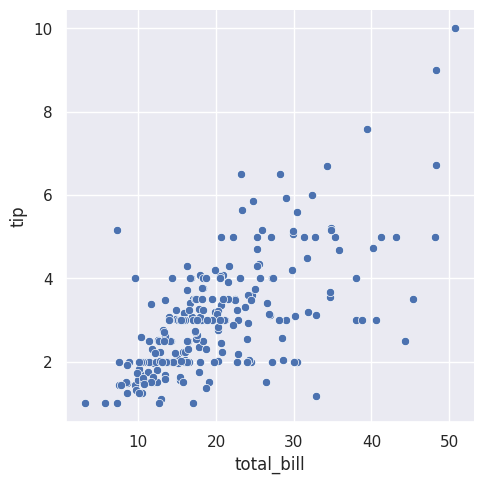

In [ ]:
sns.relplot(data=tips, x="total_bill", y="tip")

While the points are plotted in two dimensions, **another dimension can be added** to the plot by coloring the points according to a third variable. In seaborn, this is referred to as using a “`hue` semantic”, because the color of the point gains meaning:

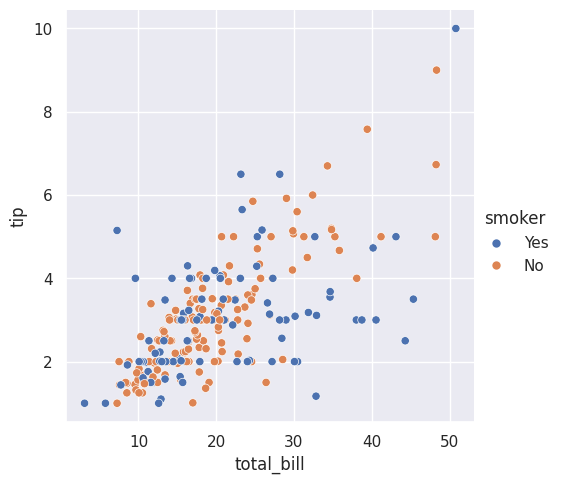

In [3]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker")

To emphasize the difference between the classes, and to improve accessibility, you can use a **different marker style** for each class:

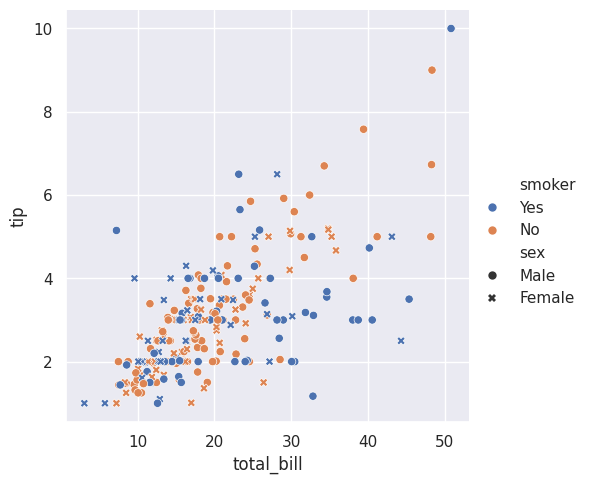

In [17]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", style="sex"
)

The third kind of semantic variable changes the `size` of each point:

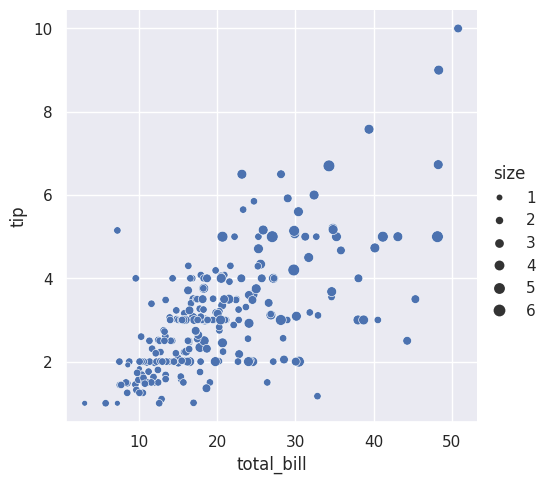

In [8]:
sns.relplot(data=tips, x="total_bill", y="tip", size="size")

Unlike with `matplotlib.pyplot.scatter()`, the literal value of the variable is not used to pick the area of the point. Instead, the range of values in data units is normalized into a range in area units. This range can be customized:

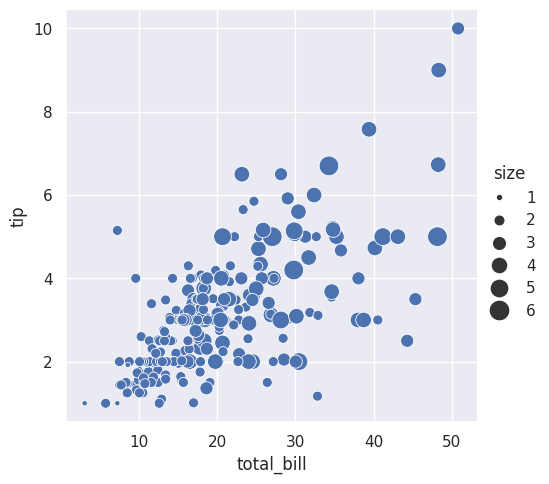

In [9]:
sns.relplot(
    data=tips, x="total_bill", y="tip",
    size="size", sizes=(15, 200)
)

More examples for customizing how the different semantics are used to show statistical relationships are shown in the [`scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn.scatterplot) API examples.

## Showing multiple relationships with facets

To show the influence of an additional variable, instead of assigning it to one of the semantic roles in the plot, use it to “facet” the visualization. This means that you make multiple axes and plot subsets of the data on each of them:

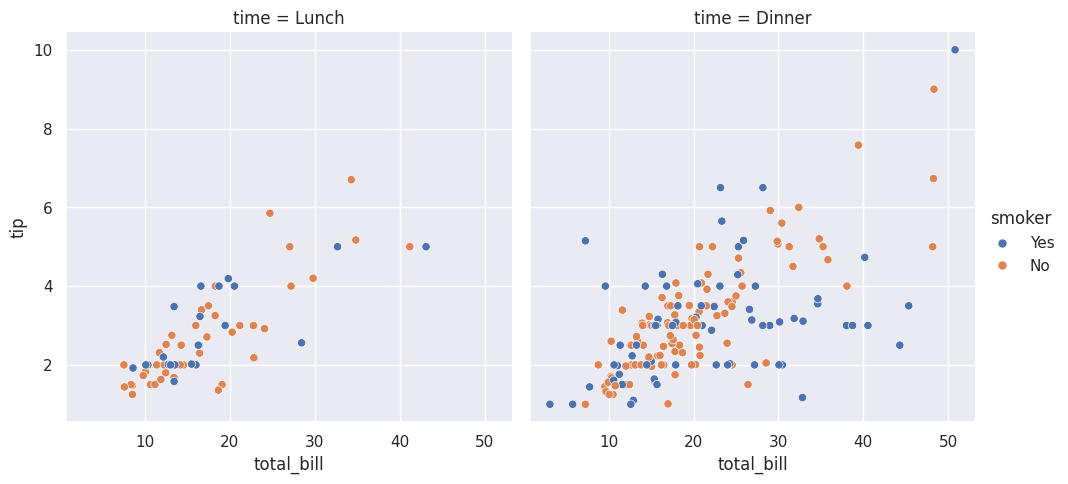

In [10]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", col="time",
)

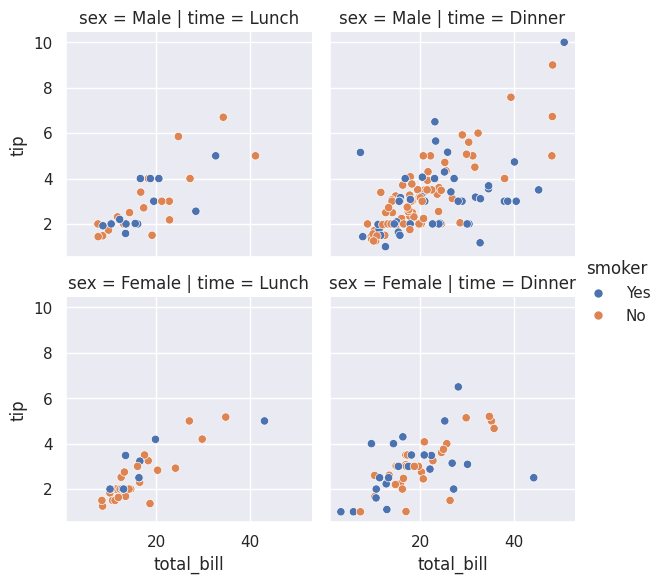

In [16]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker",
    col="time", row="sex", height=3
)

## Emphasizing continuity with line plots

Scatter plots are highly effective, but there is no universally optimal type of visualisation. **Instead, the visual representation should be adapted for the specifics of the dataset and to the question you are trying to answer with the plot**.

With some datasets, you may want to understand changes in one variable as a function of time, or a similarly continuous variable. In this situation, a good choice is to draw a line plot. In seaborn, this can be accomplished by the [`lineplot()`](https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot) function, either directly or with [`relplot()`](https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot) by setting `kind="line"`:

In [37]:
dowjones = sns.load_dataset("dowjones")
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


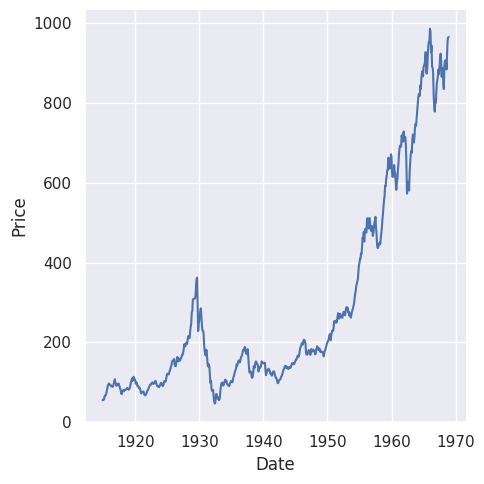

In [ ]:
sns.relplot(data=dowjones, x="Date", y="Price", kind="line")

When you want to **examine effects across many levels of a variable**, it can be a good idea to facet that variable on the columns and then “wrap” the facets into the rows:

In [34]:
fmri = sns.load_dataset("fmri")
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [35]:
fmri['subject'] = fmri['subject'].str.replace(r'^s', '', regex=True).astype(int)
fmri = fmri.sort_values(by=["subject", "timepoint", "event"])

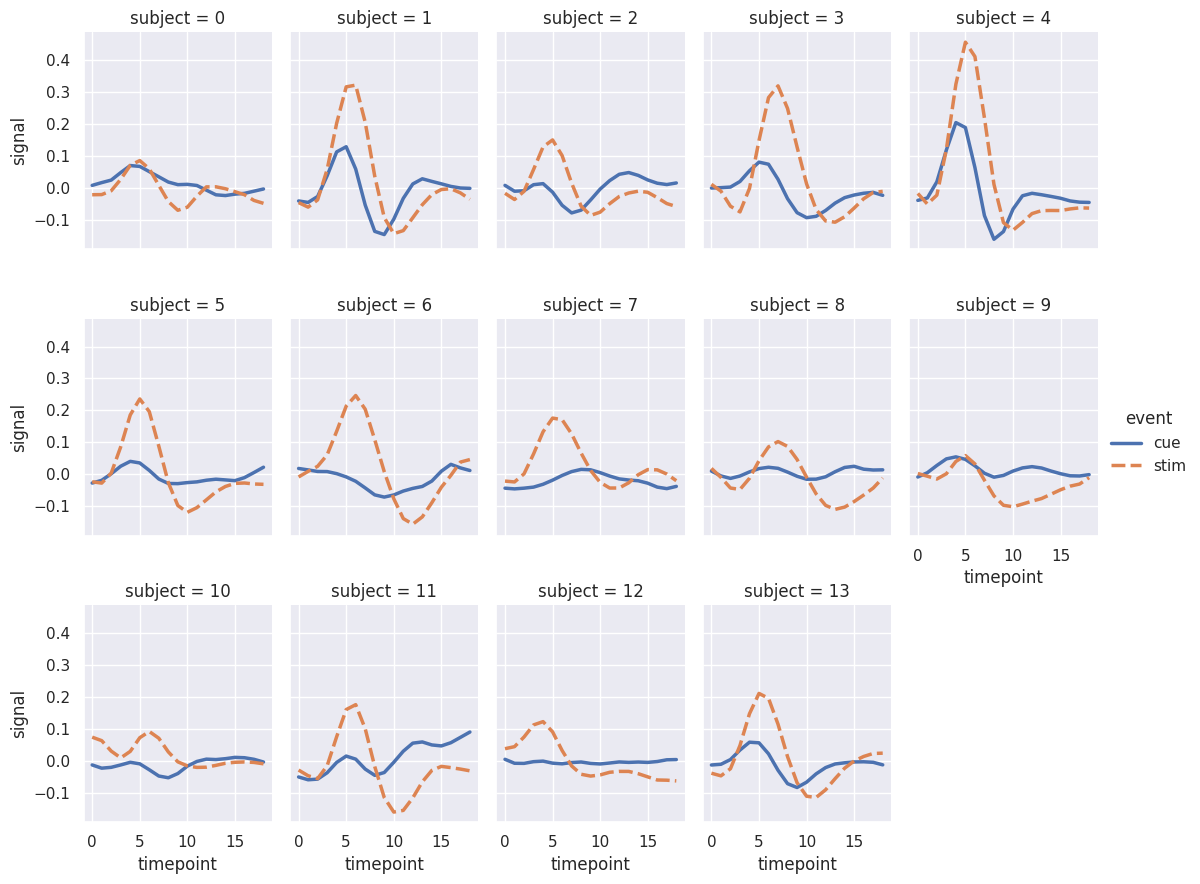

In [36]:
sns.relplot(
    data=fmri.query("region == 'frontal'"), kind="line",
    x="timepoint", y="signal", hue="event", style="event",
    col="subject", col_wrap=5,
    height=3, aspect=.75, linewidth=2.5,
)